Training samples: 15999
Testing samples: 4001
Original number of features: 4096
Reduced number of PCA features: 907
Test Accuracy: 63.81%
Confusion Matrix:
[[1277  728]
 [ 720 1276]]
Cats correctly classified: 1277
Cats incorrectly classified as dogs: 728
Dogs incorrectly classified as cats: 720
Dogs correctly classified: 1276


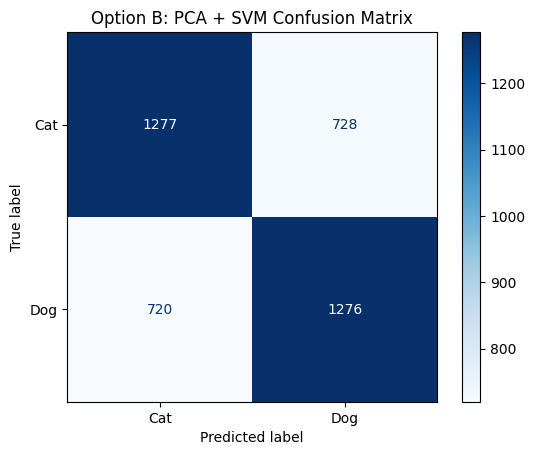

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import shutil
import random
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# Step 0: Set dataset path
# Use full path to your dataset folder
path = Path('/Users/yelin/Downloads/ecse-415-winter-2026-dog-vs-cat-classification')


# Step 1: Define original dataset folders
cats = path / 'train/train/cats'
dogs = path / 'train/train/dogs'


# Step 2: Create train/test split folders
train_cats_dir = path / 'train/train_split/cats'
train_dogs_dir = path / 'train/train_split/dogs'
test_cats_dir = path / 'train/test_split/cats'
test_dogs_dir = path / 'train/test_split/dogs'

os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(test_cats_dir, exist_ok=True)
os.makedirs(test_dogs_dir, exist_ok=True)


# Step 3: Load all image paths
cat_imgs = list(cats.iterdir())
dog_imgs = list(dogs.iterdir())

# Shuffle images
random.shuffle(cat_imgs)
random.shuffle(dog_imgs)


# Step 4: Split into training (80%) and testing (20%)
split_cats = int(len(cat_imgs) * 0.8)
split_dogs = int(len(dog_imgs) * 0.8)

train_cats = cat_imgs[:split_cats]
test_cats = cat_imgs[split_cats:]

train_dogs = dog_imgs[:split_dogs]
test_dogs = dog_imgs[split_dogs:]


# Step 5: Copy images into split folders
for img in train_cats:
    shutil.copy2(img, train_cats_dir)

for img in test_cats:
    shutil.copy2(img, test_cats_dir)

for img in train_dogs:
    shutil.copy2(img, train_dogs_dir)

for img in test_dogs:
    shutil.copy2(img, test_dogs_dir)


# Step 6: Load and preprocess images
# Convert to grayscale, resize to 64x64, flatten into 1D vector

img_size = 64

X_train = []
y_train = []
X_test = []
y_test = []

# Helper function to load images
def load_images(folder, label, image_array, label_array):
    for file_name in os.listdir(folder):
        file_path = folder / file_name
        image = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            continue
        
        image = cv2.resize(image, (img_size, img_size))
        image = image.flatten()
        
        image_array.append(image)
        label_array.append(label)


# Load training and testing data
load_images(train_cats_dir, 0, X_train, y_train)
load_images(train_dogs_dir, 1, X_train, y_train)
load_images(test_cats_dir, 0, X_test, y_test)
load_images(test_dogs_dir, 1, X_test, y_test)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# Step 7: Apply PCA (reduce dimensionality)
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Reduced number of PCA features:", X_train_pca.shape[1])


# Step 8: Train SVM classifier
classifier = SVC(kernel='rbf', C=10, gamma='scale')
classifier.fit(X_train_pca, y_train)


# Step 9: Evaluate model on test set
predictions = classifier.predict(X_test_pca)

accuracy = accuracy_score(y_test, predictions)
print(f'Test Accuracy: {100 * accuracy:.2f}%')


# Step 10: Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)

true_negative = cm[0][0]
false_positive = cm[0][1]
false_negative = cm[1][0]
true_positive = cm[1][1]

print(f'Cats correctly classified: {true_negative}')
print(f'Cats incorrectly classified as dogs: {false_positive}')
print(f'Dogs incorrectly classified as cats: {false_negative}')
print(f'Dogs correctly classified: {true_positive}')


# Step 11: Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(cmap='Blues')

plt.title('Option B: PCA + SVM Confusion Matrix')
plt.show()

NameError: name 'y' is not defined